In [1]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np


In [2]:
# fetch dataset 
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
# data (as pandas dataframes) 
X = magic_gamma_telescope.data.features 
y = magic_gamma_telescope.data.targets 
  
# metadata 
print(magic_gamma_telescope.metadata) 
  
# variable information 
print(magic_gamma_telescope.variables) 

{'uci_id': 159, 'name': 'MAGIC Gamma Telescope', 'repository_url': 'https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope', 'data_url': 'https://archive.ics.uci.edu/static/public/159/data.csv', 'abstract': 'Data are MC generated to simulate registration of high energy gamma particles in an atmospheric Cherenkov telescope', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 19020, 'num_features': 10, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2004, 'last_updated': 'Tue Dec 19 2023', 'dataset_doi': '10.24432/C52C8B', 'creators': ['R. Bock'], 'intro_paper': None, 'additional_info': {'summary': "The data are MC generated (see below) to simulate registration of high energy gamma particles in a ground-based atmospheric Cherenkov gamma telescope using the imaging technique. Cherenkov gamm

In [3]:
df = pd.concat([X, y], axis=1)
df.columns = ["fLength", "fWidth", "fSize", "fConc", "fConc1", 
               "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
cols = df.columns

# convert class to binary: gamma=1, hadron=0
df["class"] = (df["class"] == "g").astype(int)

df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


In [4]:
%pip install torch torchvision torchaudio

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
os.makedirs(os.path.expanduser("~/magic-telescope-gamma-classification/results/figures"), exist_ok=True)

FIGURES = os.path.expanduser("~/magic-telescope-gamma-classification/results/figures")

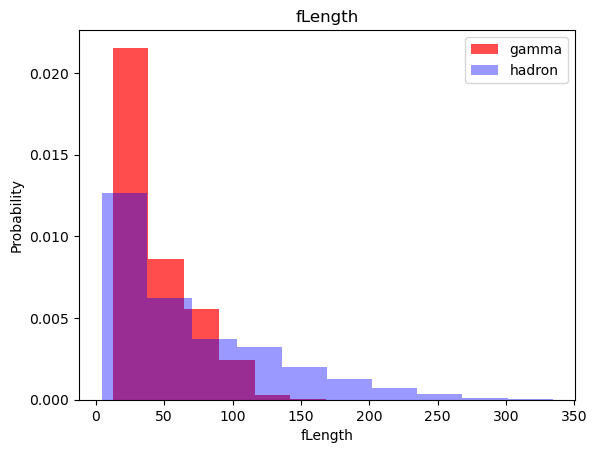

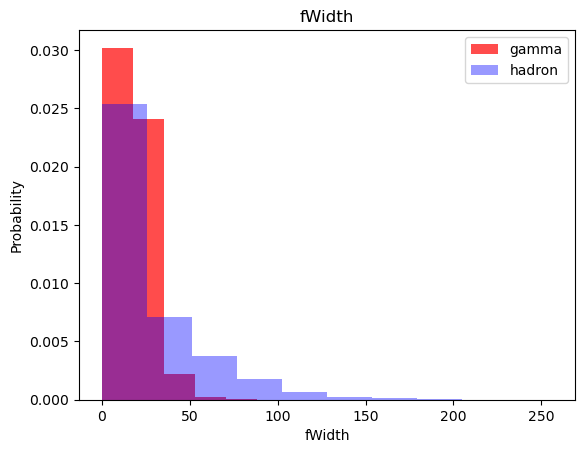

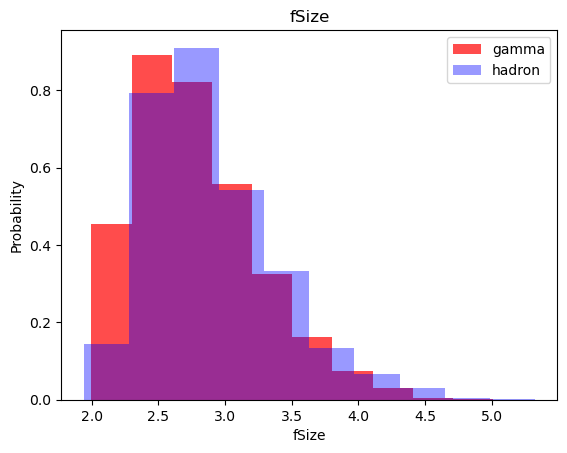

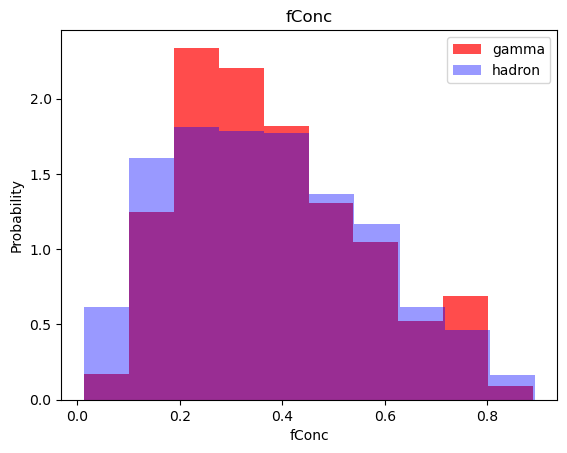

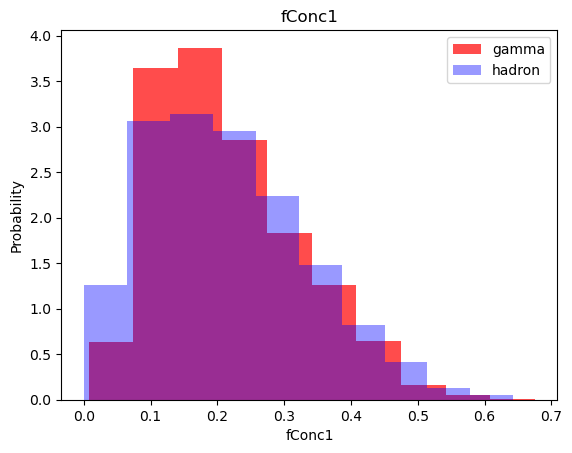

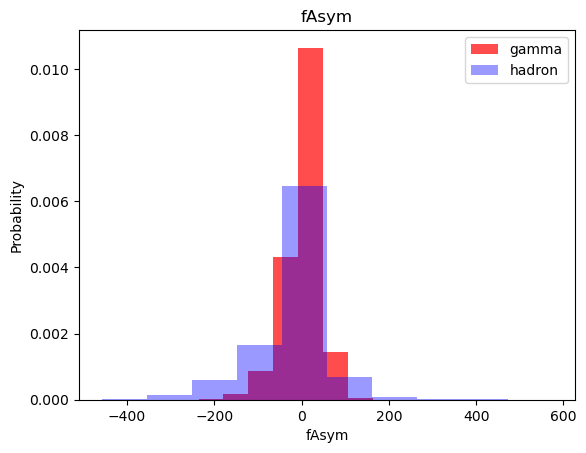

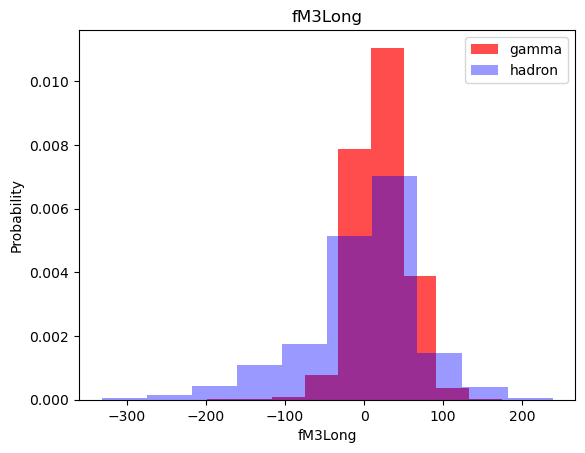

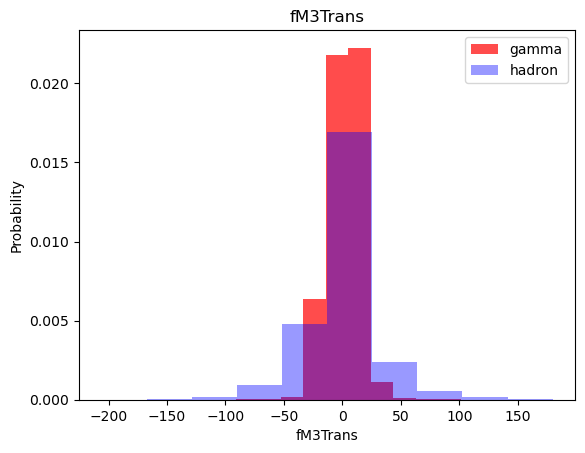

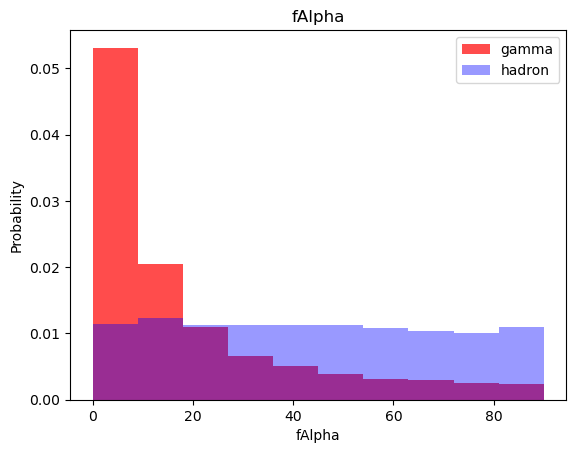

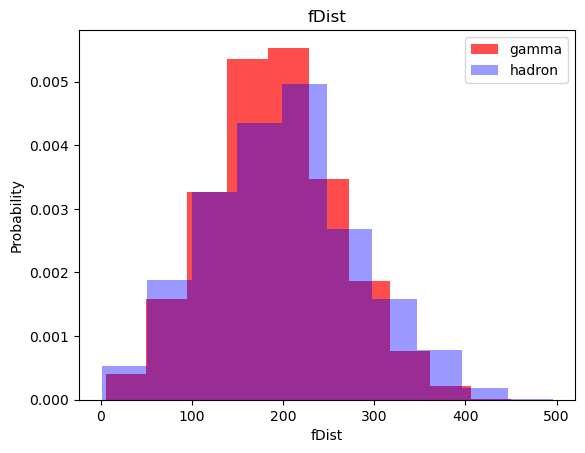

In [6]:
for label in cols[:-1]:
  plt.hist(df[df["class"]==1][label], color="red", label="gamma", alpha=0.7, density=True)
  plt.hist(df[df["class"]==0][label], color="blue", label="hadron", alpha=0.4, density=True)
  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.savefig(f"{FIGURES}/feature_distributions.png", dpi=150, bbox_inches='tight')
  plt.show()


In [7]:
"""#Training, validation and testing datasets

"""

train, validate, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

def scale_dataset(dataframe, oversample=False): #values are too disperse
  X = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  X = scaler.fit_transform(X)

  if oversample:
    ros = RandomOverSampler()
    X, y = ros.fit_resample(X, y)

  data = np.hstack((X, np.reshape (y, (-1, 1))))
  return data, X, y


train, X_train, y_train = scale_dataset(train, oversample = True)
validate, X_validate, y_validate = scale_dataset(validate, oversample = False)
test, X_test, y_test = scale_dataset(test, oversample=False)


len(y_train)
sum(y_train == 1)


/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


np.int64(7404)

In [8]:
"""#kNN - k-nearest neighbors

"""

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn_model = KNeighborsClassifier(n_neighbors=8)
knn_model = knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)
y_pred

y_test

print(classification_report(y_test, y_pred))
y_pred_knn = knn_model.predict(X_test)

              precision    recall  f1-score   support

           0       0.72      0.77      0.74      1319
           1       0.87      0.84      0.86      2485

    accuracy                           0.82      3804
   macro avg       0.80      0.80      0.80      3804
weighted avg       0.82      0.82      0.82      3804



In [9]:
"""#Naive Bayes

"""

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))
y_pred_nb = nb_model.predict(X_test)


              precision    recall  f1-score   support

           0       0.68      0.42      0.52      1319
           1       0.74      0.90      0.81      2485

    accuracy                           0.73      3804
   macro avg       0.71      0.66      0.67      3804
weighted avg       0.72      0.73      0.71      3804



In [10]:
"""#Log Regression

"""

from sklearn.linear_model import LogisticRegression

lg_model = LogisticRegression()
lg_model.fit(X_train, y_train)

y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))
y_pred_lr = lg_model.predict(X_test)



              precision    recall  f1-score   support

           0       0.67      0.70      0.69      1319
           1       0.84      0.82      0.83      2485

    accuracy                           0.78      3804
   macro avg       0.75      0.76      0.76      3804
weighted avg       0.78      0.78      0.78      3804



In [11]:
"""#SML

"""

from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

y_pred_svm = svm_model.predict(X_test)


              precision    recall  f1-score   support

           0       0.78      0.79      0.79      1319
           1       0.89      0.88      0.89      2485

    accuracy                           0.85      3804
   macro avg       0.84      0.84      0.84      3804
weighted avg       0.85      0.85      0.85      3804



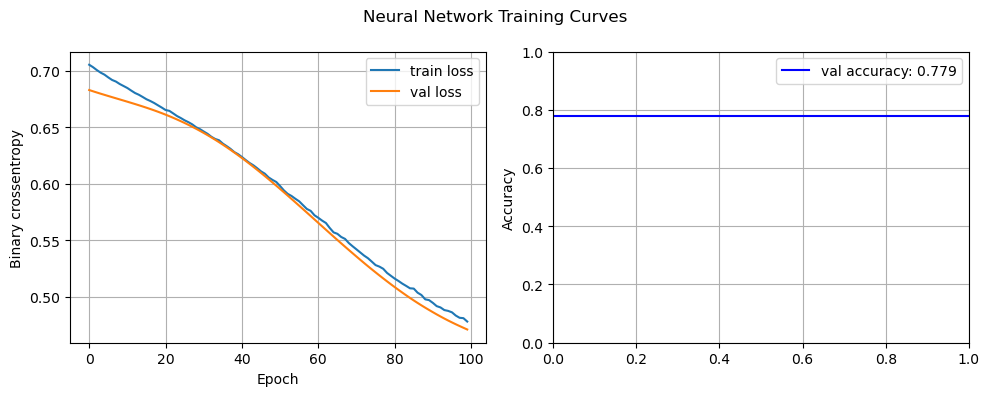

              precision    recall  f1-score   support

           0       0.68      0.72      0.70      1319
           1       0.85      0.82      0.83      2485

    accuracy                           0.78      3804
   macro avg       0.76      0.77      0.77      3804
weighted avg       0.79      0.78      0.79      3804



In [12]:


"""#Neural Network"""

# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_val_t   = torch.FloatTensor(X_validate)
y_val_t   = torch.FloatTensor(y_validate)
X_test_t  = torch.FloatTensor(X_test)

# Model
nn_model = nn.Sequential(
    nn.Linear(10, 32), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(32, 16), nn.ReLU(),
    nn.Linear(16, 1),  nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001)

# Training loop
train_losses, val_losses = [], []
for epoch in range(100):
    # Train
    nn_model.train()
    optimizer.zero_grad()
    out = nn_model(X_train_t).squeeze()
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # Validate
    nn_model.eval()
    with torch.no_grad():
        val_out = nn_model(X_val_t).squeeze()
        val_loss = criterion(val_out, y_val_t)
        val_losses.append(val_loss.item())

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(train_losses, label='train loss')
ax1.plot(val_losses,   label='val loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Binary crossentropy')
ax1.legend()
ax1.grid(True)

# Accuracy on validation
nn_model.eval()
with torch.no_grad():
    val_preds = (nn_model(X_val_t).squeeze() > 0.5).float()
    val_acc = (val_preds == y_val_t).float().mean()
    
ax2.axhline(y=val_acc.item(), color='blue', label=f'val accuracy: {val_acc:.3f}')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)
plt.suptitle('Neural Network Training Curves')
plt.tight_layout()
plt.savefig(f"{FIGURES}/nn_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# Final predictions on test set
with torch.no_grad():
    y_pred_nn = (nn_model(X_test_t).squeeze() > 0.5).numpy().astype(int)

print(classification_report(y_test, y_pred_nn))

                Accuracy  Gamma F1  Hadron F1
kNN                0.816     0.857      0.743
Naive Bayes        0.731     0.813      0.518
Logistic Reg       0.778     0.828      0.687
SVM                0.851     0.886      0.786
Neural Network     0.785     0.832      0.700


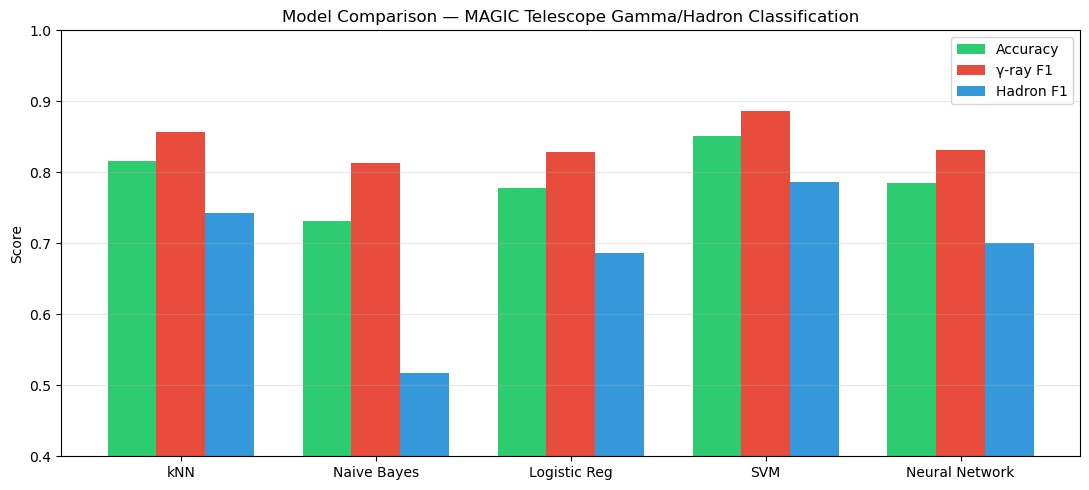

In [13]:
# ── Model Comparison Summary ──────────────────────────────────────
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# Collect all predictions (make sure each y_pred_X is saved above)
models = {
    'kNN':            y_pred_knn,
    'Naive Bayes':    y_pred_nb,
    'Logistic Reg':   y_pred_lr,
    'SVM':            y_pred_svm,
    'Neural Network': y_pred_nn,
}

# Store results
summary = {}
for name, preds in models.items():
    r = classification_report(y_test, preds, output_dict=True)
    summary[name] = {
        'Accuracy':  round(r['accuracy'], 3),
        'Gamma F1':  round(r['1']['f1-score'], 3),
        'Hadron F1': round(r['0']['f1-score'], 3),
    }

# Print table
import pandas as pd
df_results = pd.DataFrame(summary).T
print(df_results)

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(summary))
w = 0.25
ax.bar(x - w,  df_results['Accuracy'],  w, label='Accuracy',  color='#2ECC71')
ax.bar(x,      df_results['Gamma F1'],  w, label='γ-ray F1',  color='#E74C3C')
ax.bar(x + w,  df_results['Hadron F1'], w, label='Hadron F1', color='#3498DB')
ax.set_xticks(x)
ax.set_xticklabels(summary.keys())
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — MAGIC Telescope Gamma/Hadron Classification')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES}/model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()